<a href="https://colab.research.google.com/github/Sharmika-18/OasisInfobyte/blob/main/Houseprice_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import files
uploaded=files.upload()

Saving Housing.csv to Housing (1).csv


**Data Exploration & Cleaning**

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("Housing.csv")

# View first 5 rows
df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


**Feature Selection**

In [6]:
X = df.drop("price", axis=1)
y = df["price"]


**Correlation check**

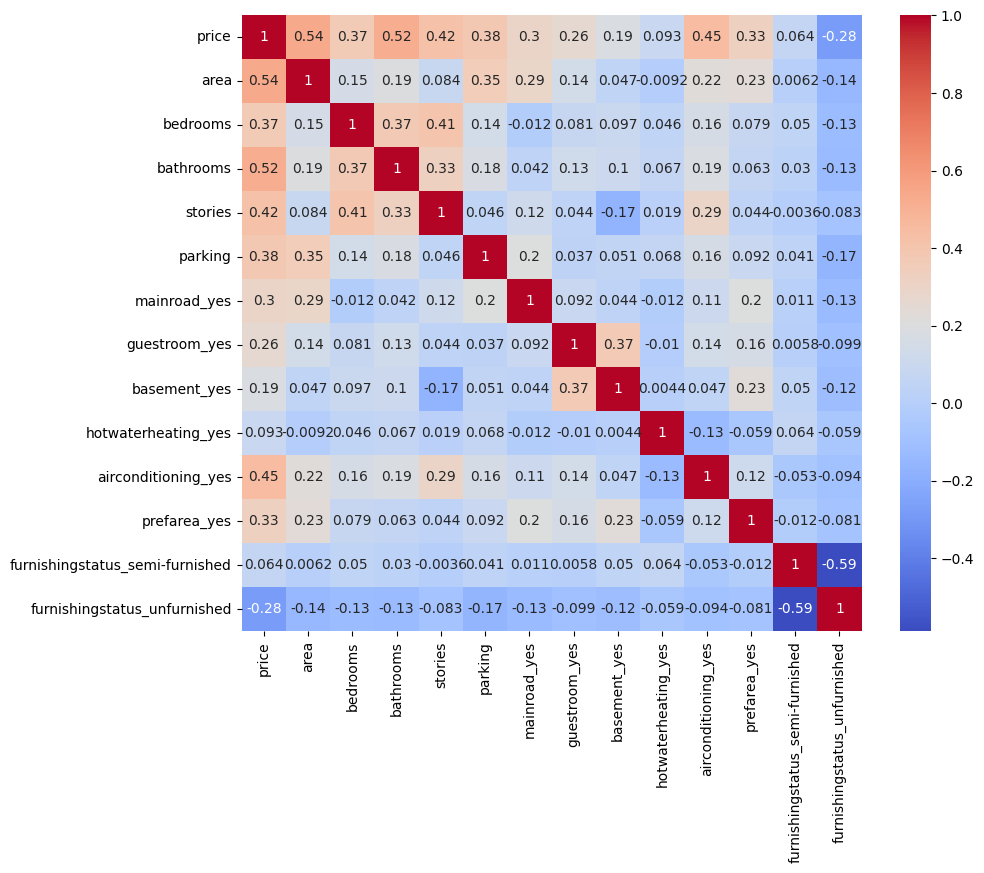

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Convert categorical columns to numeric using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

**Model Training (Linear Regression)**

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Re-define X and y from the now-processed df
# This assumes df has been preprocessed by pd.get_dummies in a previous cell (KT-wYwqW042z).
X = df.drop('price', axis=1)
y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train
model.fit(X_train, y_train)


LinearRegression()

**Model Evaluation**

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 1754318687330.6638
R2 Score: 0.6529242642153184


**Actual vs Predicted Plot**

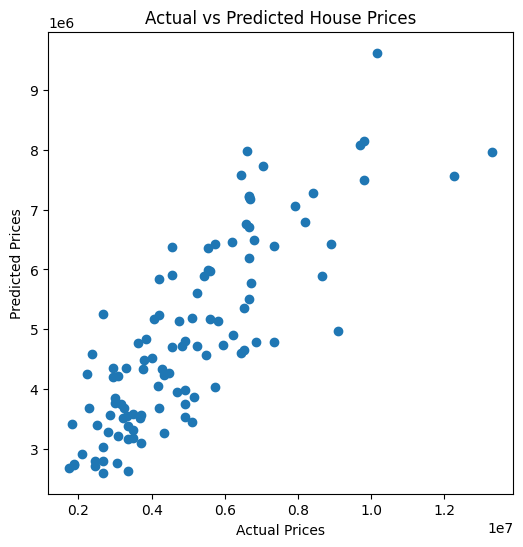

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()


**Regression Line**

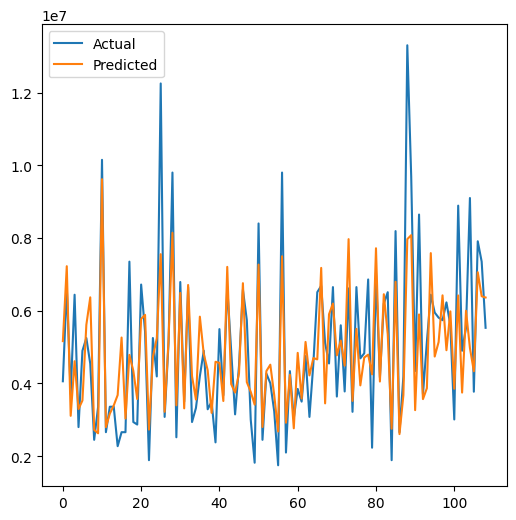

In [15]:
plt.figure(figsize=(6,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()


In [23]:
# New house data (example)
new_house = {
    'area': 7420,
    'bedrooms': 4,
    'bathrooms': 2,
    'stories': 3,
    'parking': 2,
    'mainroad_yes': 1,
    'guestroom_yes': 0,
    'basement_yes': 1,
    'hotwaterheating_yes': 0,
    'airconditioning_yes': 1,
    'prefarea_yes': 1,
    'furnishingstatus_semi-furnished': 1,
    'furnishingstatus_unfurnished': 0
}

# Convert to dataframe
new_house_df = pd.DataFrame([new_house])

# Prediction
predicted_price = model.predict(new_house_df)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 8231645.484983364


In [20]:
price_lakhs = predicted_price[0] / 100000

print("Predicted House Price:", round(price_lakhs,2), "Lakhs")

Predicted House Price: 82.32 Lakhs
